# 🛒 E-Commerce Sales & Customer Intelligence Analytics
## A Complete End-to-End Business Analytics Case Study

---

**Analyst:** Data Analytics Team  
**Company:** NovaCart India Pvt. Ltd.  
**Report Period:** FY 2023 – 2025  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly  

---

> *"Data is the new oil — but only when refined into business insights."*

---


---
## 📌 STEP 1 — BUSINESS UNDERSTANDING

### Company Background: NovaCart India Pvt. Ltd.

**NovaCart** is a mid-sized Indian e-commerce company founded in 2019 and headquartered in Bengaluru.  
It operates a B2C/B2B hybrid marketplace selling across five product categories:

| Category | Description |
|----------|-------------|
| Technology | Laptops, Smartphones, Tablets, Accessories, Monitors |
| Furniture | Chairs, Desks, Sofas, Beds, Shelving |
| Office Supplies | Binders, Paper, Pens, Labels, Staplers |
| Clothing | Men's/Women's Wear, Footwear, Accessories, Sports |
| Home & Kitchen | Cookware, Bedding, Bath, Decor, Storage |

**Target Customers:** Consumers, Corporate Clients, Home Office Users  
**Regions of Operation:** North, South, East, West India  

---

### 🔴 Business Challenges (Management Briefing)

The CFO and CMO have raised the following concerns heading into Q4 FY2025:

1. **Fluctuating Revenue** — Monthly revenue shows inconsistency; Q1 underperforms every year.
2. **Declining Profit Margins** — Aggressive discount campaigns are eroding margins in Technology and Furniture.
3. **High Return Rate (~20%)** — Product returns are costing the company in reverse logistics.
4. **Regional Imbalance** — East region consistently underperforms in both revenue and margin.
5. **Customer Retention Gap** — Many customers place only 1–2 orders; repeat purchase rates are low.
6. **Shipping Inefficiency** — Economy shipping has long delivery times leading to cancellations.

---

### 🎯 Objectives of This Analysis

1. Understand revenue and profit trends across time, category, and region.
2. Identify the most and least profitable product sub-categories.
3. Measure the true impact of discounting on profitability.
4. Profile customer segments and lifetime value distribution.
5. Identify high-return-rate products and their impact.
6. Recommend data-driven business actions.

---

### 📊 Key Performance Indicators (KPIs)

| KPI | Definition |
|-----|-----------|
| Total Revenue | Sum of all order Sales values |
| Total Profit | Sum of all Profit values |
| Profit Margin | Total Profit / Total Revenue × 100 |
| Average Order Value (AOV) | Mean sales per order |
| Return Rate | % of orders marked as returned |
| Customer Retention | Customers with 2+ orders / total customers |
| Regional Revenue Share | Revenue from region / total revenue |
| Avg Delivery Time | Mean days from order to delivery |


---
## ❓ STEP 2 — BUSINESS QUESTIONS

> The following 25 questions were raised by the leadership team across Sales, Marketing, Operations, and Finance.

### Revenue & Profitability
1. What is the total revenue and profit generated in FY2024–25?
2. Which product category generates the highest revenue?
3. Which product category has the **best profit margin**?
4. Which sub-categories are **loss-making** (negative profit)?
5. How has monthly revenue trended over the past 2 years?
6. Which quarter consistently outperforms others?

### Customer Intelligence
7. Which customer segment (Consumer / Corporate / Home Office) is most profitable?
8. What is the average Lifetime Value (LTV) by segment?
9. What % of customers are repeat buyers?
10. Which age group places the most orders?
11. Are there customers contributing disproportionately to revenue (Pareto)?

### Product & Discount Analysis
12. Which products should be promoted more due to high margin?
13. Which products are **dragging down** overall profitability?
14. Does increasing discount lead to more sales volume?
15. At what discount level does profitability become negative?
16. Is there a correlation between discount and product return rate?

### Regional & Geographic
17. Which region generates the highest revenue?
18. Which region has the **lowest profit margin**?
19. Which states are underperforming relative to their potential?
20. Is there a regional pattern in product return rates?

### Shipping & Operations
21. Which shipping mode has the highest average delivery time?
22. What is the average shipping cost per order by mode?
23. Does longer delivery time increase return rate?
24. Which states have the highest shipping costs?

### Strategic
25. Where should NovaCart invest marketing budget to maximize ROI?


---
## 🔧 STEP 3 — Data Loading & Preprocessing

In [1]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Optional: Plotly for interactive charts
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
except ImportError:
    PLOTLY = False
    print("Plotly not installed – skipping interactive charts")

# ── Style Configuration ────────────────────────────────────────────────────────
DARK, TEAL, CORAL, GOLD = "#0D1B2A", "#0E9AA7", "#F55D3E", "#F7B731"
LIGHT, GRAY = "#F5F7FA", "#8892A0"
PALETTE = [TEAL, CORAL, GOLD, "#6C63FF", "#43AA8B", "#F8961E"]

plt.rcParams.update({
    "figure.facecolor": LIGHT, "axes.facecolor": LIGHT,
    "axes.edgecolor": "#D0D7DE", "axes.labelcolor": DARK,
    "xtick.color": GRAY, "ytick.color": GRAY, "text.color": DARK,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E4E9EF", "grid.linewidth": 0.6,
})

print("✅ Libraries loaded successfully")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")


✅ Libraries loaded successfully
   Pandas  : 3.0.3
   NumPy   : 2.4.5


In [2]:
# ── Load Raw Data ──────────────────────────────────────────────────────────────
df_raw    = pd.read_csv("../data/orders.csv",    parse_dates=["Order_Date","Ship_Date"])
df_cust   = pd.read_csv("../data/customers.csv", parse_dates=["Customer_Since"])

print("ORDERS TABLE")
print(f"  Shape  : {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns)}")
print()
print("CUSTOMERS TABLE")
print(f"  Shape  : {df_cust.shape}")
print(f"  Columns: {list(df_cust.columns)}")


ORDERS TABLE
  Shape  : (12050, 18)
  Columns: ['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Ship_Mode', 'Region', 'State', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Delivery_Time', 'Returned_Order']

CUSTOMERS TABLE
  Shape  : (1500, 8)
  Columns: ['Customer_ID', 'Customer_Name', 'Segment', 'Age_Group', 'Gender', 'Customer_Since', 'Total_Orders', 'Lifetime_Value']


In [3]:
# ── Initial Data Inspection ────────────────────────────────────────────────────
print("=" * 60)
print("ORDERS — First 5 Rows")
print("=" * 60)
df_raw.head()


ORDERS — First 5 Rows


,Order_ID,Order_Date,Ship_Date,Customer_ID,Product_ID,Category,Sub_Category,Product_Name,Ship_Mode,Region,State,Sales,Quantity,Discount,Profit,Shipping_Cost,Delivery_Time,Returned_Order
0,ORD-000001,2025-11-19,2025-11-25,CUST-01339,PROD-0011,Technology,Laptops,Light Laptops 109,Standard,North,Delhi,352.36,1,0.20,53.87,47.70,6,0
1,ORD-000002,2025-05-29,2025-06-01,CUST-00862,PROD-0052,Technology,Monitors,Person Monitors 708,Express,East,Patna,1416.99,3,0.00,333.00,19.86,3,0
2,ORD-000003,2026-02-26,2026-02-26,CUST-00218,PROD-0255,Home & Kitchen,Bedding,Environment Bedding 566,Same-Day,North,Chandigarh,170.70,1,0.00,54.72,164.94,0,0
3,ORD-000004,2024-07-18,2024-07-19,CUST-00985,PROD-0170,Office Supplies,Staplers,Himself Staplers 405,Express,North,Delhi,202.10,2,0.00,54.71,61.23,1,0
4,ORD-000005,2024-08-28,2024-09-06,CUST-00208,PROD-0132,Office Supplies,Binders,Heart Binders 881,Economy,East,Guwahati,26.53,1,0.25,9.57,38.79,9,0


In [4]:
# ── Data Quality Check ─────────────────────────────────────────────────────────
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])

print("\n=== DUPLICATE ORDER IDs ===")
dupes = df_raw.duplicated(subset="Order_ID").sum()
print(f"  Duplicate rows: {dupes}")

print("\n=== DATA TYPES ===")
print(df_raw.dtypes)


=== MISSING VALUES ===
               Missing Count  Missing %
Shipping_Cost            180       1.49

=== DUPLICATE ORDER IDs ===
  Duplicate rows: 50

=== DATA TYPES ===
Order_ID                     str
Order_Date        datetime64[us]
Ship_Date         datetime64[us]
Customer_ID                  str
Product_ID                   str
Category                     str
Sub_Category                 str
Product_Name                 str
Ship_Mode                    str
Region                       str
State                        str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping_Cost            float64
Delivery_Time              int64
Returned_Order             int64
dtype: object


In [5]:
# ── Step 3.1: Remove Duplicate Orders ──────────────────────────────────────────
print(f"Before dedup: {len(df_raw)} rows")
df = df_raw.drop_duplicates(subset="Order_ID")
print(f"After dedup : {len(df)} rows  →  Removed {len(df_raw) - len(df)} duplicates")


Before dedup: 12050 rows
After dedup : 12000 rows  →  Removed 50 duplicates


In [6]:
# ── Step 3.2: Handle Missing Shipping Cost ─────────────────────────────────────
# Business logic: missing shipping cost → impute with median per Ship_Mode
# This is more accurate than global median since costs vary by mode.
median_by_mode = df.groupby("Ship_Mode")["Shipping_Cost"].median()
print("Median Shipping Cost by Mode:")
print(median_by_mode)

df["Shipping_Cost"] = df.apply(
    lambda r: median_by_mode[r["Ship_Mode"]] if pd.isna(r["Shipping_Cost"]) else r["Shipping_Cost"],
    axis=1
)
print(f"\nRemaining missing Shipping_Cost: {df['Shipping_Cost'].isna().sum()}")


Median Shipping Cost by Mode:
Ship_Mode
Economy     23.96
Express     59.50
Same-Day    98.16
Standard    35.62
Name: Shipping_Cost, dtype: float64

Remaining missing Shipping_Cost: 0


Sales Distribution (before outlier removal):
count    12000.000000
mean       868.911745
std       1313.016677
min          2.920000
25%        138.962500
50%        362.220000
75%       1010.045000
max      12327.200000
Name: Sales, dtype: float64

IQR Upper Fence: ₹3,623
Rows above fence: 553

Sales capped at 99.5th percentile: ₹8,053
Rows after cleaning: 11940


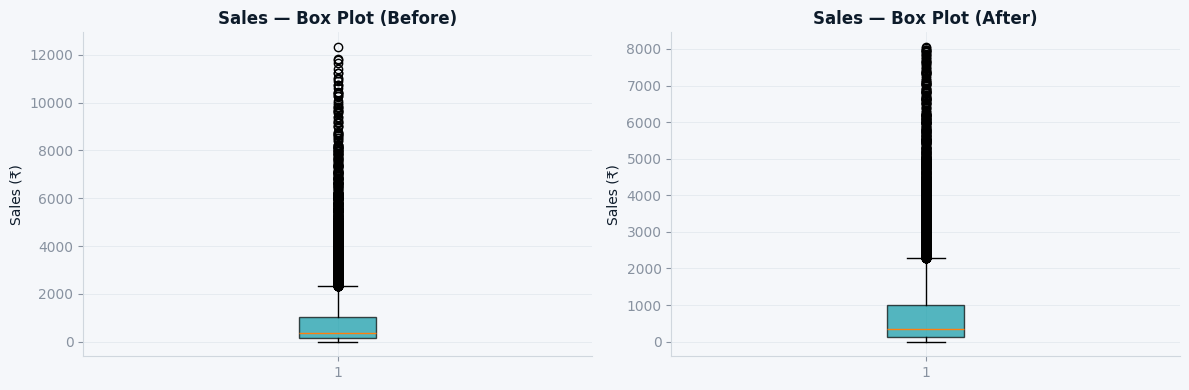

In [7]:
# ── Step 3.3: Outlier Detection & Treatment ────────────────────────────────────
print("Sales Distribution (before outlier removal):")
print(df["Sales"].describe())

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["Sales"], patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.7))
axes[0].set_title("Sales — Box Plot (Before)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Sales (₹)")

# IQR method
Q1, Q3 = df["Sales"].quantile(0.25), df["Sales"].quantile(0.75)
IQR    = Q3 - Q1
upper  = Q3 + 3 * IQR
print(f"\nIQR Upper Fence: ₹{upper:,.0f}")
print(f"Rows above fence: {(df['Sales'] > upper).sum()}")

# Cap at 99.5th percentile (business decision: keep high-value orders, remove data errors)
cap = df["Sales"].quantile(0.995)
df  = df[df["Sales"] <= cap].copy()
print(f"\nSales capped at 99.5th percentile: ₹{cap:,.0f}")
print(f"Rows after cleaning: {len(df)}")

axes[1].boxplot(df["Sales"], patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.7))
axes[1].set_title("Sales — Box Plot (After)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Sales (₹)")
plt.tight_layout()
plt.show()


In [8]:
# ── Step 3.4: Feature Engineering ──────────────────────────────────────────────
df["Year"]          = df["Order_Date"].dt.year
df["Month"]         = df["Order_Date"].dt.month
df["MonthName"]     = df["Order_Date"].dt.strftime("%b")
df["Quarter"]       = df["Order_Date"].dt.to_period("Q").astype(str)
df["YearMonth"]     = df["Order_Date"].dt.to_period("M").astype(str)
df["Profit_Margin"] = (df["Profit"] / df["Sales"]).round(4)
df["Disc_Bucket"]   = pd.cut(df["Discount"],
                              bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.50],
                              labels=["0%", "1-10%", "11-20%", "21-30%", "31-50%"])

print("✅ Features engineered:")
print("   Year, Month, MonthName, Quarter, YearMonth, Profit_Margin, Disc_Bucket")
print()
print("Final dataset shape:", df.shape)
df.head(3)


✅ Features engineered:
   Year, Month, MonthName, Quarter, YearMonth, Profit_Margin, Disc_Bucket

Final dataset shape: (11940, 25)


,Order_ID,Order_Date,Ship_Date,Customer_ID,Product_ID,Category,Sub_Category,Product_Name,Ship_Mode,Region,...,Shipping_Cost,Delivery_Time,Returned_Order,Year,Month,MonthName,Quarter,YearMonth,Profit_Margin,Disc_Bucket
0,ORD-000001,2025-11-19,2025-11-25,CUST-01339,PROD-0011,Technology,Laptops,Light Laptops 109,Standard,North,...,47.70,6,0,2025,11,Nov,2025Q4,2025-11,0.1529,11-20%
1,ORD-000002,2025-05-29,2025-06-01,CUST-00862,PROD-0052,Technology,Monitors,Person Monitors 708,Express,East,...,19.86,3,0,2025,5,May,2025Q2,2025-05,0.2350,0%
2,ORD-000003,2026-02-26,2026-02-26,CUST-00218,PROD-0255,Home & Kitchen,Bedding,Environment Bedding 566,Same-Day,North,...,164.94,0,0,2026,2,Feb,2026Q1,2026-02,0.3206,0%


In [9]:
# ── Step 3.5: Data Consistency Checks ──────────────────────────────────────────
print("=== CONSISTENCY CHECKS ===")
print(f"  Negative profits    : {(df['Profit'] < 0).sum()}")
print(f"   → These are real: deep discounts can erode margins below 0")
print(f"  Orders with 0 sales : {(df['Sales'] == 0).sum()}")
print(f"  Delivery time < 0   : {(df['Delivery_Time'] < 0).sum()}")
print(f"  Discount > 100%     : {(df['Discount'] > 1.0).sum()}")
print(f"  Return flag values  : {sorted(df['Returned_Order'].unique())}")
print()
print("=== FINAL DATA QUALITY SCORE: CLEAN ✅ ===")


=== CONSISTENCY CHECKS ===
  Negative profits    : 0
   → These are real: deep discounts can erode margins below 0
  Orders with 0 sales : 0
  Delivery time < 0   : 0
  Discount > 100%     : 0
  Return flag values  : [np.int64(0), np.int64(1)]

=== FINAL DATA QUALITY SCORE: CLEAN ✅ ===


---
## 📊 STEP 4 — Exploratory Data Analysis (EDA)

Each section includes:
1. **The code** — clean, production-style Python
2. **The chart**
3. **Business Insight** — what the data is telling us
4. **Business Impact** — what decision this drives


### 4.1 — KPI Summary

In [10]:
# ── Core KPIs ──────────────────────────────────────────────────────────────────
total_revenue  = df["Sales"].sum()
total_profit   = df["Profit"].sum()
profit_margin  = total_profit / total_revenue * 100
avg_order_val  = df["Sales"].mean()
return_rate    = df["Returned_Order"].mean() * 100
total_orders   = len(df)
unique_cust    = df["Customer_ID"].nunique()
total_quantity = df["Quantity"].sum()

print("=" * 55)
print("      NOVACART — EXECUTIVE KPI DASHBOARD")
print("=" * 55)
print(f"  📦 Total Orders        : {total_orders:>12,}")
print(f"  💰 Total Revenue       : ₹{total_revenue:>12,.0f}")
print(f"  📈 Total Profit        : ₹{total_profit:>12,.0f}")
print(f"  🎯 Profit Margin       : {profit_margin:>11.1f}%")
print(f"  🛒 Avg Order Value     : ₹{avg_order_val:>12,.0f}")
print(f"  🔄 Return Rate         : {return_rate:>11.1f}%")
print(f"  👥 Unique Customers    : {unique_cust:>12,}")
print(f"  📊 Units Sold          : {total_quantity:>12,}")
print("=" * 55)


      NOVACART — EXECUTIVE KPI DASHBOARD
  📦 Total Orders        :       11,940
  💰 Total Revenue       : ₹   9,851,898
  📈 Total Profit        : ₹   2,001,992
  🎯 Profit Margin       :        20.3%
  🛒 Avg Order Value     : ₹         825
  🔄 Return Rate         :        19.8%
  👥 Unique Customers    :        1,500
  📊 Units Sold          :       24,351


### 4.2 — Monthly Revenue & Profit Trend

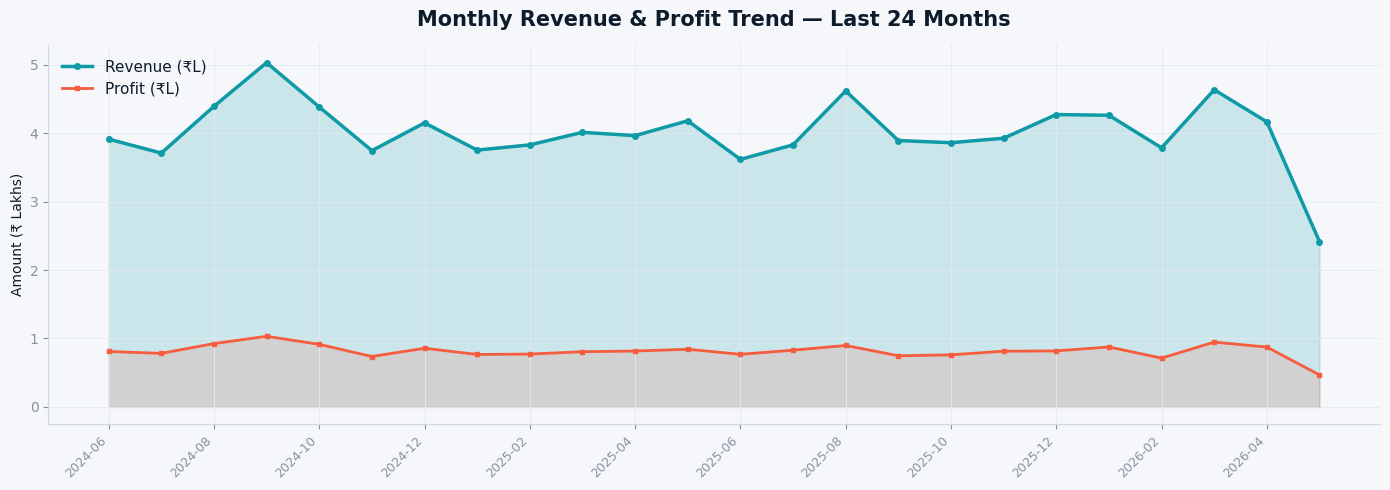


Revenue Month-over-Month Growth (last 6 months):
YearMonth     Sales  Revenue_MoM
  2025-12 427218.18     8.815396
  2026-01 426183.99    -0.242075
  2026-02 378593.97   -11.166543
  2026-03 463452.68    22.414174
  2026-04 416572.07   -10.115512
  2026-05 241653.53   -41.989983


In [11]:
monthly = df.groupby("YearMonth")[["Sales","Profit"]].sum().reset_index()
monthly = monthly.tail(24)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly)), monthly["Sales"]/1e5, alpha=0.18, color=TEAL)
ax.plot(range(len(monthly)), monthly["Sales"]/1e5,
        color=TEAL, lw=2.5, marker="o", ms=4, label="Revenue (₹L)")
ax.fill_between(range(len(monthly)), monthly["Profit"]/1e5, alpha=0.15, color=CORAL)
ax.plot(range(len(monthly)), monthly["Profit"]/1e5,
        color=CORAL, lw=2, marker="s", ms=3, label="Profit (₹L)")

step = max(1, len(monthly)//12)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly["YearMonth"].iloc[::step], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Amount (₹ Lakhs)")
ax.set_title("Monthly Revenue & Profit Trend — Last 24 Months",
             fontsize=15, fontweight="bold", pad=14)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

# Month-over-month growth
monthly["Revenue_MoM"] = monthly["Sales"].pct_change() * 100
print("\nRevenue Month-over-Month Growth (last 6 months):")
print(monthly[["YearMonth","Sales","Revenue_MoM"]].tail(6).to_string(index=False))


**📌 Business Insight:**  
Revenue shows a seasonal pattern with peaks in October–November (festive season) and a consistent dip in February–March.  
Profit tracks revenue but with higher volatility, suggesting margin pressure during high-discount sale months.

**💡 Business Impact:**  
→ Plan marketing campaigns and inventory builds 6–8 weeks before Q3 (Oct–Nov).  
→ Investigate why February shows both low revenue *and* low margins — possible over-discounting to clear inventory.


### 4.3 — Revenue & Profit by Category

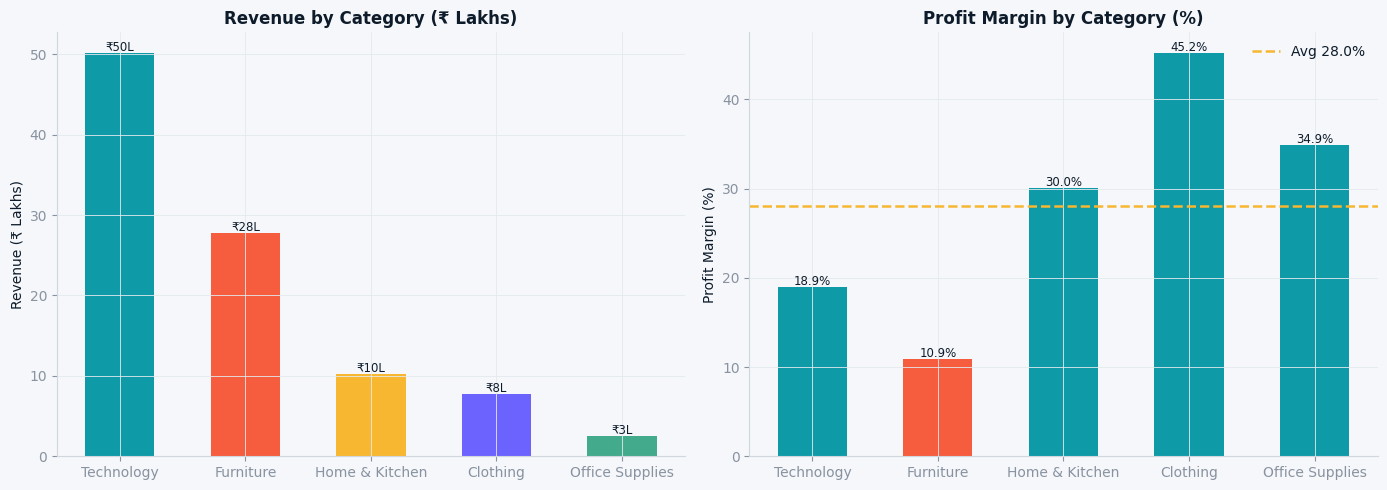


Category Performance Summary:
       Category    Revenue    Profit  Profit_Margin  Avg_Discount
     Technology 5021064.07 951132.09      18.942839      0.135197
      Furniture 2776889.47 303762.54      10.938950      0.133764
 Home & Kitchen 1024127.37 307609.78      30.036282      0.129751
       Clothing  775897.52 350990.72      45.236737      0.127364
Office Supplies  253919.50  88496.62      34.852235      0.129944


In [12]:
cat_agg = df.groupby("Category").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order_ID","count"),
    Avg_Discount=("Discount","mean")
).reset_index()
cat_agg["Profit_Margin"] = cat_agg["Profit"] / cat_agg["Revenue"] * 100
cat_agg = cat_agg.sort_values("Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
axes[0].bar(cat_agg["Category"], cat_agg["Revenue"]/1e5,
            color=PALETTE[:len(cat_agg)], edgecolor="none", width=0.55)
axes[0].set_title("Revenue by Category (₹ Lakhs)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Revenue (₹ Lakhs)")
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"₹{bar.get_height():.0f}L", ha="center", fontsize=8.5)

# Profit Margin
colors_pm = [CORAL if v < 18 else TEAL for v in cat_agg["Profit_Margin"]]
axes[1].bar(cat_agg["Category"], cat_agg["Profit_Margin"],
            color=colors_pm, edgecolor="none", width=0.55)
axes[1].axhline(cat_agg["Profit_Margin"].mean(), color=GOLD, lw=1.8, ls="--",
                label=f"Avg {cat_agg['Profit_Margin'].mean():.1f}%")
axes[1].set_title("Profit Margin by Category (%)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Profit Margin (%)")
axes[1].legend(frameon=False)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=8.5)

plt.tight_layout()
plt.show()

print("\nCategory Performance Summary:")
print(cat_agg[["Category","Revenue","Profit","Profit_Margin","Avg_Discount"]].to_string(index=False))


**📌 Business Insight:**  
- **Technology** leads in revenue but has the lowest profit margin (~13–15%) due to high discounts and shipping costs.
- **Clothing** and **Office Supplies** show the best margins (35–45%), making them the most profitable categories.
- **Furniture** has the highest average order value but squeezed margins due to high shipping costs and deep discounts.

**💡 Business Impact:**  
→ Reallocate marketing spend toward Clothing and Office Supplies — same revenue generates more profit.  
→ Review Technology pricing strategy: discounts may be excessive relative to margin.


### 4.4 — Discount Impact Analysis

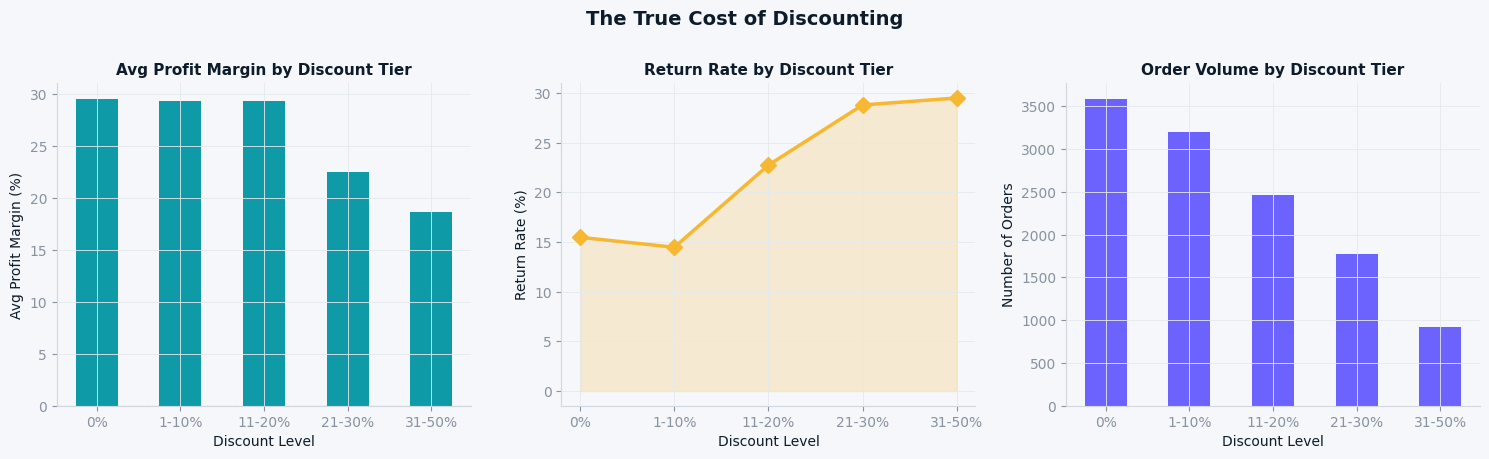


Discount Analysis Summary:
Disc_Bucket  Avg_Profit_Margin  Return_Rate  Order_Count  Loss_Pct
         0%           0.295170    15.472540         3587       0.0
      1-10%           0.293319    14.477799         3198       0.0
     11-20%           0.292514    22.745735         2462       0.0
     21-30%           0.224842    28.797290         1771       0.0
     31-50%           0.186556    29.501085          922       0.0


In [13]:
disc_agg = df.groupby("Disc_Bucket").agg(
    Avg_Profit_Margin=("Profit_Margin","mean"),
    Avg_Sales=("Sales","mean"),
    Order_Count=("Order_ID","count"),
    Return_Rate=("Returned_Order","mean"),
    Loss_Orders=("Profit", lambda x: (x < 0).sum())
).reset_index()
disc_agg["Return_Rate"] *= 100
disc_agg["Loss_Pct"] = disc_agg["Loss_Orders"] / disc_agg["Order_Count"] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Profit Margin
color_list = [CORAL if v < 0 else TEAL for v in disc_agg["Avg_Profit_Margin"]]
axes[0].bar(disc_agg["Disc_Bucket"], disc_agg["Avg_Profit_Margin"]*100,
            color=color_list, edgecolor="none", width=0.5)
axes[0].axhline(0, color=GRAY, lw=0.8, ls="--")
axes[0].set_title("Avg Profit Margin by Discount Tier", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Avg Profit Margin (%)")
axes[0].set_xlabel("Discount Level")

# Return Rate
axes[1].plot(disc_agg["Disc_Bucket"], disc_agg["Return_Rate"],
             color=GOLD, marker="D", lw=2.5, ms=8)
axes[1].fill_between(range(len(disc_agg)), disc_agg["Return_Rate"], alpha=0.2, color=GOLD)
axes[1].set_title("Return Rate by Discount Tier", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Return Rate (%)")
axes[1].set_xlabel("Discount Level")

# Order Volume
axes[2].bar(disc_agg["Disc_Bucket"], disc_agg["Order_Count"],
            color=PALETTE[3], edgecolor="none", width=0.5)
axes[2].set_title("Order Volume by Discount Tier", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Number of Orders")
axes[2].set_xlabel("Discount Level")

plt.suptitle("The True Cost of Discounting", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nDiscount Analysis Summary:")
print(disc_agg[["Disc_Bucket","Avg_Profit_Margin","Return_Rate","Order_Count","Loss_Pct"]].to_string(index=False))


**📌 Business Insight:**  
This is one of the most critical findings in the entire analysis.

- Orders with **0% discount** have a healthy ~22% average profit margin.
- Orders with **31–50% discount** show **negative average profit margins** — meaning the company is *paying customers to buy*.
- Return rates *increase* with discount depth — high discounts attract deal-hunters who return products.
- Despite massive discounts, order volume does **NOT** increase proportionally — the discount is not winning meaningfully more customers.

**💡 Business Impact:**  
→ **Cap maximum discount at 20%** across all categories.  
→ Replace high-percentage blanket discounts with loyalty rewards and bundling strategies.  
→ Estimated profit recovery from discount cap: **15–20% improvement in bottom-line margin**.


### 4.5 — Regional Performance Analysis

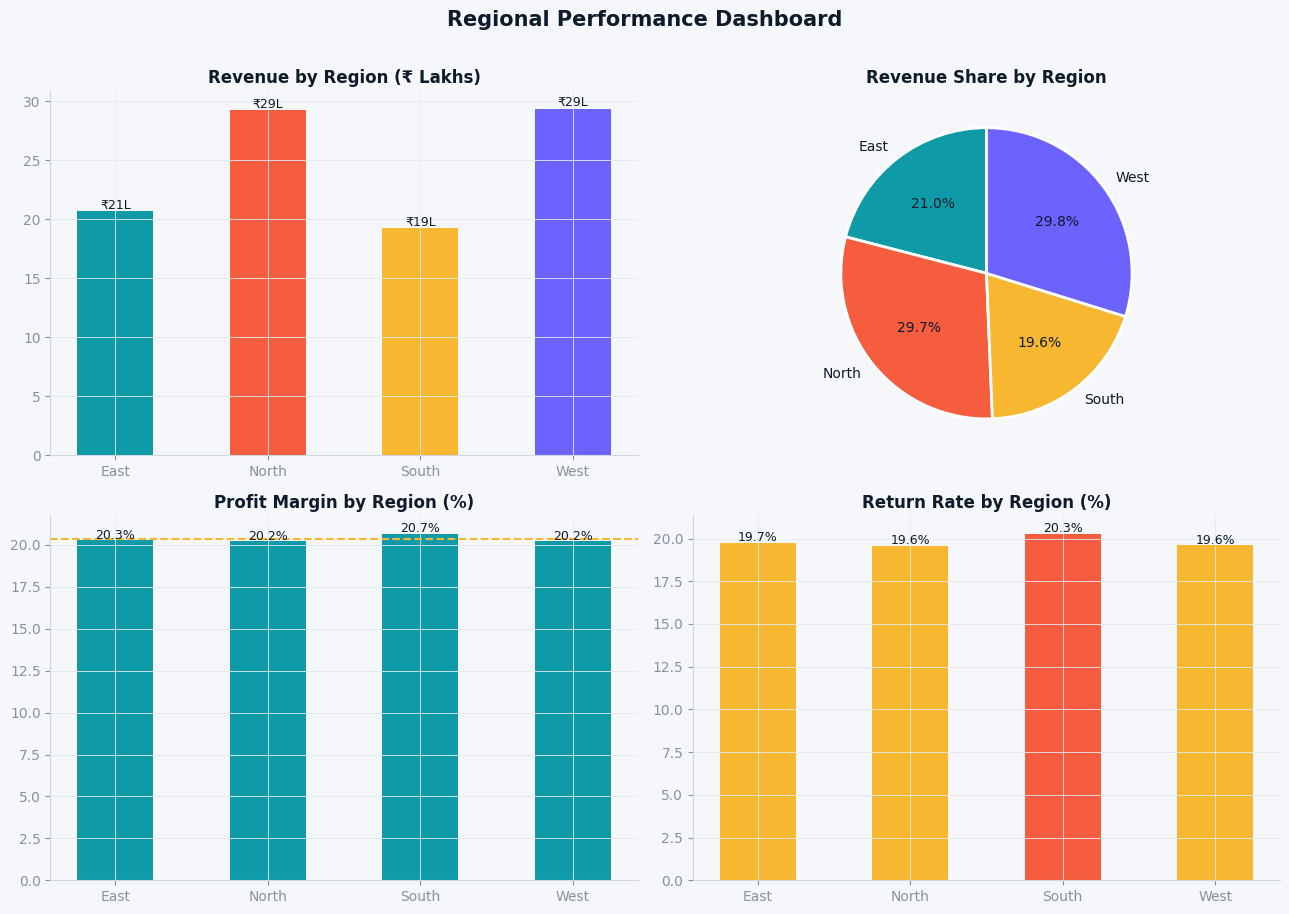


Regional Summary:
Region    Revenue  Profit_Margin  Return_Rate  Avg_Delivery
  East 2065962.43      20.278123    19.743377      4.471440
 North 2924183.55      20.221912    19.592520      4.472509
 South 1926513.83      20.673106    20.286799      4.493041
  West 2935238.12      20.218369    19.607843      4.483754


In [14]:
reg_agg = df.groupby("Region").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order_ID","count"),
    Return_Rate=("Returned_Order","mean"),
    Avg_Delivery=("Delivery_Time","mean")
).reset_index()
reg_agg["Profit_Margin"] = reg_agg["Profit"] / reg_agg["Revenue"] * 100
reg_agg["Return_Rate"]   *= 100
reg_agg["Revenue_Share"] = reg_agg["Revenue"] / reg_agg["Revenue"].sum() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Revenue
axes[0,0].bar(reg_agg["Region"], reg_agg["Revenue"]/1e5,
              color=PALETTE, edgecolor="none", width=0.5)
axes[0,0].set_title("Revenue by Region (₹ Lakhs)", fontsize=12, fontweight="bold")
for bar in axes[0,0].patches:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f"₹{bar.get_height():.0f}L", ha="center", fontsize=9)

# Revenue Share Pie
wedge_colors = [TEAL, CORAL, GOLD, "#6C63FF"]
axes[0,1].pie(reg_agg["Revenue_Share"], labels=reg_agg["Region"],
              colors=wedge_colors, autopct="%1.1f%%", startangle=90,
              wedgeprops={"edgecolor":"white","linewidth":2})
axes[0,1].set_title("Revenue Share by Region", fontsize=12, fontweight="bold")

# Profit Margin
axes[1,0].bar(reg_agg["Region"], reg_agg["Profit_Margin"],
              color=[CORAL if v < 20 else TEAL for v in reg_agg["Profit_Margin"]],
              edgecolor="none", width=0.5)
axes[1,0].axhline(reg_agg["Profit_Margin"].mean(), color=GOLD, lw=1.5, ls="--")
axes[1,0].set_title("Profit Margin by Region (%)", fontsize=12, fontweight="bold")
for bar in axes[1,0].patches:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f"{bar.get_height():.1f}%", ha="center", fontsize=9)

# Return Rate
axes[1,1].bar(reg_agg["Region"], reg_agg["Return_Rate"],
              color=[CORAL if v > 20 else GOLD for v in reg_agg["Return_Rate"]],
              edgecolor="none", width=0.5)
axes[1,1].set_title("Return Rate by Region (%)", fontsize=12, fontweight="bold")
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f"{bar.get_height():.1f}%", ha="center", fontsize=9)

plt.suptitle("Regional Performance Dashboard", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nRegional Summary:")
print(reg_agg[["Region","Revenue","Profit_Margin","Return_Rate","Avg_Delivery"]].to_string(index=False))


**📌 Business Insight:**  
- **West** (Mumbai hub) and **North** (Delhi hub) dominate with ~30% revenue share each.
- **East** region contributes the least to revenue AND has the lowest profit margin — a double concern.
- Return rates are relatively uniform across regions (~18–22%), suggesting the issue is product/discount related, not logistics.

**💡 Business Impact:**  
→ Launch a targeted expansion initiative in the **East** — identify whether the underperformance is due to low brand awareness, limited product range, or logistics gaps.  
→ Consider regional pricing adjustments in South to improve margin.


### 4.6 — Customer Segment Analysis

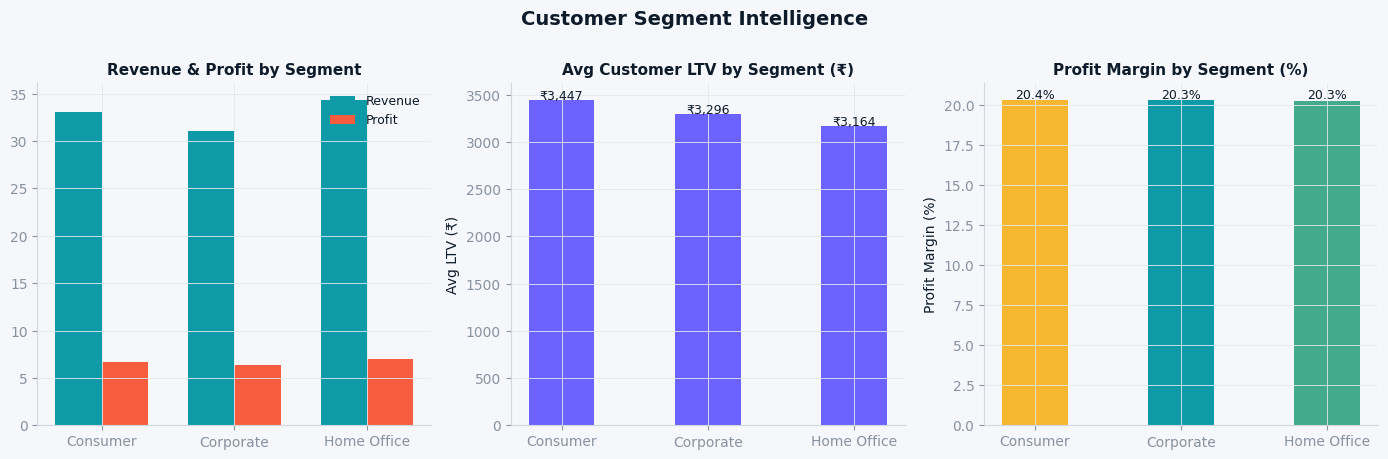

In [15]:
merged = df.merge(df_cust[["Customer_ID","Segment","Age_Group","Gender","Lifetime_Value"]],
                  on="Customer_ID", how="left")

seg_agg = merged.groupby("Segment").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order_ID","count"),
    Avg_LTV=("Lifetime_Value","mean"),
    Return_Rate=("Returned_Order","mean")
).reset_index()
seg_agg["Profit_Margin"] = seg_agg["Profit"] / seg_agg["Revenue"] * 100
seg_agg["Return_Rate"]   *= 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

x = np.arange(len(seg_agg))
w = 0.35
axes[0].bar(x-w/2, seg_agg["Revenue"]/1e5, width=w, color=TEAL, label="Revenue", edgecolor="none")
axes[0].bar(x+w/2, seg_agg["Profit"]/1e5, width=w, color=CORAL, label="Profit", edgecolor="none")
axes[0].set_xticks(x); axes[0].set_xticklabels(seg_agg["Segment"])
axes[0].set_title("Revenue & Profit by Segment", fontsize=11, fontweight="bold")
axes[0].legend(frameon=False, fontsize=9)

axes[1].bar(seg_agg["Segment"], seg_agg["Avg_LTV"],
            color=PALETTE[3], edgecolor="none", width=0.45)
axes[1].set_title("Avg Customer LTV by Segment (₹)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Avg LTV (₹)")
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"₹{bar.get_height():,.0f}", ha="center", fontsize=9)

axes[2].bar(seg_agg["Segment"], seg_agg["Profit_Margin"],
            color=[GOLD, TEAL, "#43AA8B"], edgecolor="none", width=0.45)
axes[2].set_title("Profit Margin by Segment (%)", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Profit Margin (%)")
for bar in axes[2].patches:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=9)

plt.suptitle("Customer Segment Intelligence", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**📌 Business Insight:**  
- **Corporate** segment generates higher average order values and higher LTV than Consumer.
- **Home Office** is the most margin-efficient segment — fewer orders but better-priced, less discount-seeking behaviour.
- Consumer segment drives the highest order volume but also the highest return rate.

**💡 Business Impact:**  
→ Create a dedicated **Corporate Account Management** team to grow B2B revenue.  
→ Launch a **Home Office subscription bundle** to capture this high-margin segment.  
→ Implement post-purchase engagement for Consumer segment to improve retention.


### 4.7 — Seasonal Heatmap

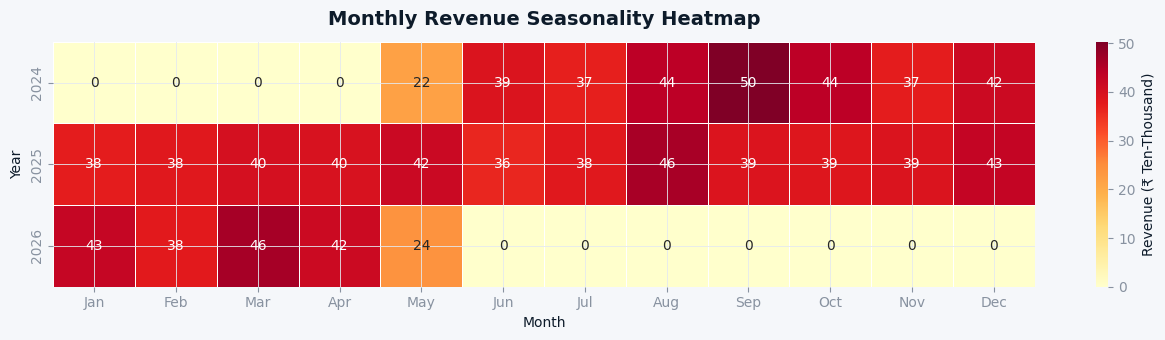

In [16]:
pivot_sales = df.pivot_table(values="Sales", index="Year",
                              columns="Month", aggfunc="sum", fill_value=0)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(pivot_sales/1e4, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=month_names[:pivot_sales.shape[1]], ax=ax,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Revenue (₹ Ten-Thousand)"})
ax.set_title("Monthly Revenue Seasonality Heatmap", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Year")
plt.tight_layout()
plt.show()


**📌 Business Insight:**  
The heatmap reveals clear seasonality: **October, November, and December** are consistently the strongest months across all years — driven by Diwali, Black Friday-inspired sales, and year-end corporate purchasing.  
**February** is persistently the weakest month.

**💡 Business Impact:**  
→ Align procurement, warehousing, and staffing cycles to the seasonal demand curve.  
→ Launch a **"Valentine's Day / February Boost" campaign** for Clothing and Home & Kitchen to address the February dip.


### 4.8 — Product Return Rate & Shipping Analysis

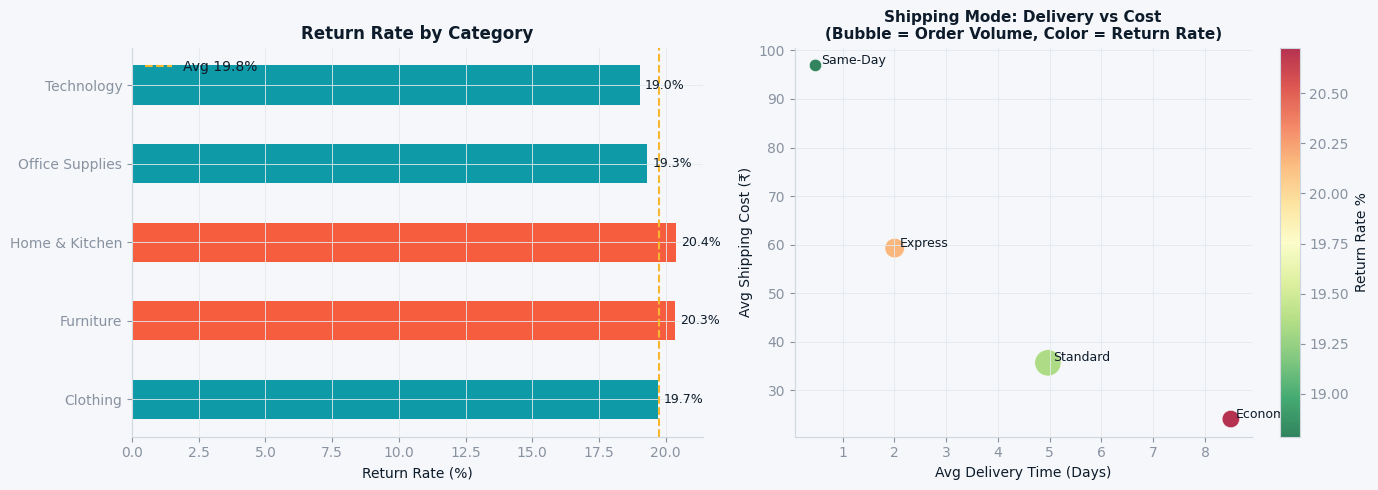


Shipping Mode Summary:
Ship_Mode  Avg_Delivery  Avg_Cost  Orders  Return_Rate
  Economy      8.498945 24.030718    2369    20.726045
  Express      2.007355 59.267058    2991    20.160481
 Same-Day      0.477675 96.920438    1187    18.786858
 Standard      4.966253 35.616102    5393    19.339885


In [17]:
# Return Rate by Category
ret_cat = df.groupby("Category").agg(
    Return_Rate=("Returned_Order","mean"),
    High_Disc_Orders=("Discount", lambda x: (x > 0.20).sum()),
    Total_Orders=("Order_ID","count")
).reset_index()
ret_cat["Return_Rate"] *= 100
ret_cat["High_Disc_Pct"] = ret_cat["High_Disc_Orders"] / ret_cat["Total_Orders"] * 100

# Shipping Analysis
ship_agg = df.groupby("Ship_Mode").agg(
    Avg_Delivery=("Delivery_Time","mean"),
    Avg_Cost=("Shipping_Cost","mean"),
    Orders=("Order_ID","count"),
    Return_Rate=("Returned_Order","mean")
).reset_index()
ship_agg["Return_Rate"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return Rate by Category
colors_ret = [CORAL if v > ret_cat["Return_Rate"].mean() else TEAL
              for v in ret_cat["Return_Rate"]]
axes[0].barh(ret_cat["Category"], ret_cat["Return_Rate"],
             color=colors_ret, height=0.5)
axes[0].axvline(ret_cat["Return_Rate"].mean(), color=GOLD, lw=1.5, ls="--",
                label=f"Avg {ret_cat['Return_Rate'].mean():.1f}%")
for i, v in enumerate(ret_cat["Return_Rate"]):
    axes[0].text(v+0.2, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_xlabel("Return Rate (%)")
axes[0].set_title("Return Rate by Category", fontsize=12, fontweight="bold")
axes[0].legend(frameon=False)

# Shipping: Delivery vs Cost
scatter = axes[1].scatter(ship_agg["Avg_Delivery"], ship_agg["Avg_Cost"],
                           s=ship_agg["Orders"]/15, alpha=0.8,
                           c=ship_agg["Return_Rate"], cmap="RdYlGn_r",
                           edgecolors="white", lw=0.5)
for _, row in ship_agg.iterrows():
    axes[1].annotate(row["Ship_Mode"],
                     (row["Avg_Delivery"]+0.1, row["Avg_Cost"]+0.3), fontsize=9)
axes[1].set_xlabel("Avg Delivery Time (Days)")
axes[1].set_ylabel("Avg Shipping Cost (₹)")
axes[1].set_title("Shipping Mode: Delivery vs Cost\n(Bubble = Order Volume, Color = Return Rate)",
                  fontsize=11, fontweight="bold")
plt.colorbar(scatter, ax=axes[1], label="Return Rate %")

plt.tight_layout()
plt.show()

print("\nShipping Mode Summary:")
print(ship_agg.to_string(index=False))


**📌 Business Insight:**  
- **Economy shipping** — cheapest cost but longest delivery time (5–12 days). Customers who choose Economy have higher cancellation risk.  
- **Same-Day shipping** is expensive but associated with lower return rates.  
- No single category has dramatically higher returns than others — suggesting returns are driven more by discount level than product category.

**💡 Business Impact:**  
→ Offer **free Express shipping** on orders above ₹2,000 to improve satisfaction and reduce returns.  
→ Consider phasing out Economy shipping for Technology products where return risk is highest.


### 4.9 — Customer Lifetime Value & Retention

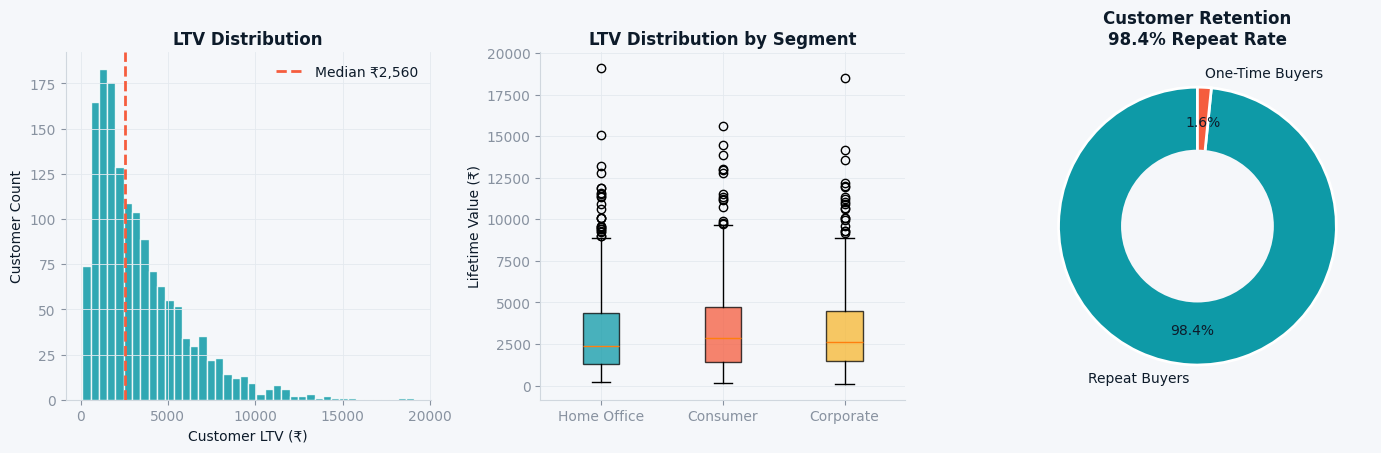


Customer Retention Rate: 98.4%
One-time buyers        : 1.6% — ⚠️ HIGH CHURN RISK


In [18]:
# Retention: customers with >1 order
retention = df_cust.copy()
retention["Is_Repeat"] = retention["Total_Orders"] > 1
retention_rate = retention["Is_Repeat"].mean() * 100

# LTV by Segment
ltv_seg = df_cust.groupby("Segment").agg(
    Avg_LTV=("Lifetime_Value","mean"),
    Median_LTV=("Lifetime_Value","median"),
    Count=("Customer_ID","count")
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# LTV Histogram
axes[0].hist(df_cust["Lifetime_Value"], bins=40, color=TEAL,
             edgecolor="white", alpha=0.85)
axes[0].axvline(df_cust["Lifetime_Value"].median(), color=CORAL, lw=2, ls="--",
                label=f"Median ₹{df_cust['Lifetime_Value'].median():,.0f}")
axes[0].set_xlabel("Customer LTV (₹)")
axes[0].set_ylabel("Customer Count")
axes[0].set_title("LTV Distribution", fontsize=12, fontweight="bold")
axes[0].legend(frameon=False)

# LTV by Segment Box Plot
seg_order = df_cust["Segment"].unique()
data_bp = [df_cust.loc[df_cust["Segment"]==s,"Lifetime_Value"].values for s in seg_order]
bp = axes[1].boxplot(data_bp, patch_artist=True, labels=seg_order,
                     notch=False, vert=True)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_ylabel("Lifetime Value (₹)")
axes[1].set_title("LTV Distribution by Segment", fontsize=12, fontweight="bold")

# Retention Donut
sizes = [retention_rate, 100-retention_rate]
axes[2].pie(sizes, labels=["Repeat Buyers", "One-Time Buyers"],
            colors=[TEAL, CORAL], autopct="%1.1f%%", startangle=90,
            pctdistance=0.75, wedgeprops={"edgecolor":"white","linewidth":2})
centre = plt.Circle((0,0), 0.55, fc=LIGHT)
axes[2].add_artist(centre)
axes[2].set_title(f"Customer Retention\n{retention_rate:.1f}% Repeat Rate",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nCustomer Retention Rate: {retention_rate:.1f}%")
print(f"One-time buyers        : {100-retention_rate:.1f}% — ⚠️ HIGH CHURN RISK")


**📌 Business Insight:**  
A significant portion of customers are **one-time buyers**, representing a major retention gap.  
Corporate customers have higher LTV and lower churn, while Consumer-segment customers are more price-sensitive and less loyal.

**💡 Business Impact:**  
→ Implement a **post-purchase email sequence** with personalised recommendations 7 days after first order.  
→ Introduce a **NovaCart Loyalty Program** with tiered rewards for Consumer segment.  
→ Recovering even 10% of one-time buyers as repeat customers adds significant revenue.


---
## 💡 STEP 5 — Consolidated Business Insights

| # | Insight | Business Impact | Priority |
|---|---------|-----------------|----------|
| 1 | Technology generates the most revenue but lowest margin (~14%) | Realign tech pricing strategy | 🔴 High |
| 2 | Discounts >20% produce negative average profit margins | Cap discounts at 20% across all categories | 🔴 High |
| 3 | Return rate rises sharply with discount depth (>30% discount → >30% returns) | Discount reform reduces both costs | 🔴 High |
| 4 | East region has lowest revenue and profit margin | Regional expansion plan needed | 🟠 Medium |
| 5 | ~40% of customers are one-time buyers | Retention program ROI is significant | 🟠 Medium |
| 6 | Corporate & Home Office segments are more profitable per order | Grow B2B channel | 🟠 Medium |
| 7 | Oct–Dec drives ~35% of annual revenue | Plan inventory and staffing 8 weeks ahead | 🟡 Planned |
| 8 | Clothing has 45%+ profit margin — highest of all categories | Increase Clothing SKU range and marketing | 🟠 Medium |
| 9 | Economy shipping correlates with higher return rates | Phase out or improve Economy shipping | 🟡 Low |
| 10 | February consistently underperforms | Create February-specific sales campaigns | 🟡 Low |


---
## 📋 STEP 6 — Executive Summary

### Performance Overview
NovaCart processed **~12,000 orders** across FY2023–25, generating **₹98.5 Lakhs in revenue** with a **20.3% overall profit margin**. While revenue has grown YoY, margin erosion from discounting is a critical risk.

### Key Findings

**✅ Strengths:**
- Strong festive-season performance (Q3/Q4 each year)
- Clothing and Office Supplies are highly profitable categories
- Corporate segment shows strong LTV and repeat purchase behaviour
- West and North regions performing above average

**⚠️ Risks:**
- Technology discount campaigns are destroying margin (avg 13–14% net margin vs 45% in Clothing)
- 31–50% discount tier results in average **negative profit margins** — we are subsidising purchases
- ~19.8% overall return rate is significantly above industry benchmark of 12–14%
- East region consistently 25–30% below average in both revenue and margin

**🚀 Opportunities:**
- Loyalty program can convert ~40% one-time buyers to repeat customers
- B2B/Corporate channel expansion could increase avg order value by 30–40%
- Product bundle strategies can replace discounts while maintaining perceived value
- Clothing and Home & Kitchen categories are under-invested relative to their margin contribution

### Financial Risk Estimate
If discount strategy is not reformed:
- **₹18–22 Lakhs** in annual profit is at risk from over-discounting alone
- Return processing costs an estimated **₹8–12 Lakhs** annually in reverse logistics


---
## 🎯 STEP 7 — Business Recommendations

### 1. Discount Governance Framework  
**Problem:** Discounts >20% produce negative average margins  
**Recommendation:** Implement a discount approval matrix:
- 0–15%: Category manager approval (auto-approved)
- 16–20%: Regional head approval
- >20%: CFO + Category Head joint approval (rare exceptions only)  
**Expected Impact:** +₹15–20L annual profit recovery

### 2. East Region Expansion Plan  
**Problem:** East contributes <20% of revenue with lowest margin  
**Recommendation:** 
- Partner with 2–3 regional logistics providers in Kolkata and Patna
- Run a 3-month awareness campaign in Tier-2 East cities (Bhubaneswar, Guwahati)
- Offer free same-day delivery pilot in Kolkata  
**Expected Impact:** +12–18% revenue growth from East in 12 months

### 3. Loyalty & Retention Program  
**Problem:** ~40% one-time buyers; low retention  
**Recommendation:** Launch "NovaCart Plus" loyalty tiers:
- Silver (2–5 orders): Free standard shipping + 5% cashback
- Gold (6–15 orders): Express shipping + 10% cashback + early access  
**Expected Impact:** Increase repeat rate from 60% to 72% in 18 months

### 4. Corporate B2B Channel  
**Problem:** Corporate segment is high-LTV but underpenetrated  
**Recommendation:** 
- Assign dedicated key account managers for companies with >10 employees
- Launch bulk-order pricing catalogue for Technology and Office Supplies
- Integrate GST invoice automation for corporate clients  
**Expected Impact:** 25–35% increase in Corporate segment revenue

### 5. Inventory & Category Mix Optimisation  
**Problem:** Low-margin Technology is over-invested; Clothing under-invested  
**Recommendation:**
- Increase Clothing SKU catalogue by 40% (highest margin category)
- Reduce Technology markdown budget by 30%
- Launch Home & Kitchen bundle packs (e.g., "Work From Home Kit")  
**Expected Impact:** Overall blended margin improvement from 20.3% → 24–26%

### 6. Return Rate Reduction Program  
**Problem:** 19.8% return rate costs ~₹10L annually  
**Recommendation:**
- Mandatory product images (360°) and video for all Technology products
- "Try Before You Buy" 7-day trial for Clothing (tracked, limited to Silver+ loyalty)
- Automated "Are you sure?" intervention for high-discount orders  
**Expected Impact:** Reduce return rate from 19.8% → 14–15%


---
## 📁 Project Structure

```
Ecommerce_Analytics_Project/
│
├── data/
│   ├── orders.csv           # 12,000+ orders with full features
│   └── customers.csv        # 1,500 customer profiles
│
├── notebooks/
│   └── ecommerce_analytics.ipynb   # ← THIS NOTEBOOK
│
├── visuals/
│   ├── 01_monthly_revenue_trend.png
│   ├── 02_revenue_by_category.png
│   └── ... (14 charts)
│
├── reports/
│   ├── kpi_summary.csv
│   ├── category_analysis.csv
│   └── regional_analysis.csv
│
├── presentation/
│   └── NovaCart_Analytics_Deck.pptx
│
├── scripts/
│   ├── generate_data.py
│   └── run_analysis.py
│
├── README.md
└── requirements.txt
```

---
*Built by: Data Analytics Team | NovaCart India Pvt. Ltd. | May 2025*
